<a href="https://colab.research.google.com/github/Gowtham13042007/cron_job/blob/main/Outliers_and_apache_spark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

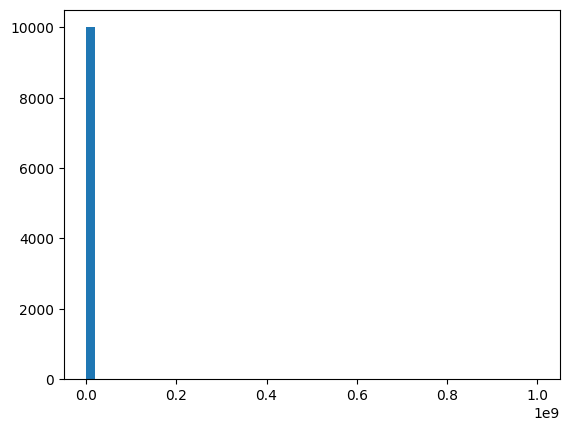

In [ ]:
import numpy as np

incomes=np.random.normal(27000,15000,10000)
incomes=np.append(incomes,[1000000000])

import matplotlib.pyplot as plt

plt.hist(incomes,50)
plt.show()

In [ ]:
incomes.mean()

np.float64(127213.5691063925)

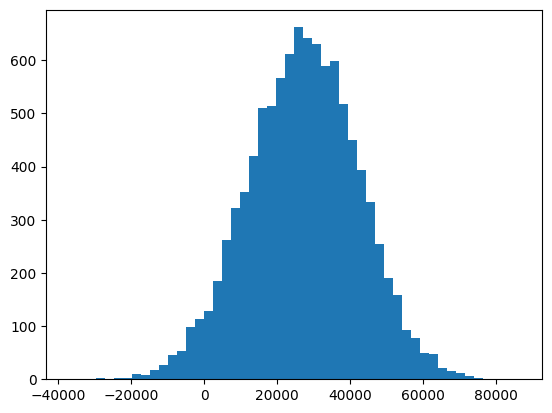

In [ ]:
def reject_outliers(data):
  u=np.median(data)
  s=np.std(data)
  filtered=[e for e in data if (u-2*s<e<u+2*s)]
  return filtered
filtered=reject_outliers(incomes)
plt.hist(filtered,50)
plt.show()

In [ ]:
np.mean(filtered)

np.float64(27226.29046330315)

In [ ]:
!pip install pyspark

Pyspark DecisionTrees


In [ ]:
from pyspark.mllib.regression import LabeledPoint
from pyspark.mllib.tree import DecisionTree
from pyspark import SparkConf,SparkContext
from numpy import array

conf=SparkConf().setMaster("local").setAppName("SparkDecisionTreeRegression")
sc=SparkContext(conf=conf)

ValueError: Cannot run multiple SparkContexts at once; existing SparkContext(app=SparkDecisionTreeRegression, master=local) created by __init__ at /tmp/ipykernel_1283/842597519.py:7 

In [ ]:
def binary(YN):
  if(YN=='Y'):
    return 1
  else:
    return 0

def mapEducation(degree):
  if(degree=='BS'):
    return 1
  elif(degree=='MS'):
    return 2
  elif(degree=='PhD'):
    return 3
  else:
    return 4

def createLabled(fields):
  yearsExperience=int(fields[0])
  employed=binary(fields[1])
  previousEmployers=int(fields[2])
  educationLevel=mapEducation(fields[3])
  topTier=binary(fields[4])
  interned=binary(fields[5])
  hired=binary(fields[6])
  return LabeledPoint(hired,[yearsExperience,employed,previousEmployers,educationLevel,topTier,interned]) #label,features

url = "https://raw.githubusercontent.com/PacktPublishing/Hands-On-Data-Science-and-Python-Machine-Learning/master/PastHires.csv"
local_path = "/content/PastHires.csv"
import urllib.request
urllib.request.urlretrieve(url, local_path)
rawData=sc.textFile(local_path)
print(rawData)
header=rawData.first()
rawData=rawData.filter(lambda x:x!=header)
csvData=rawData.map(lambda x:x.split(','))
trainingData=csvData.map(createLabled)

testingCandidates=[array([10,1,3,1,0,0])]
testingData=sc.parallelize(testingCandidates)

model=DecisionTree.trainClassifier(trainingData,numClasses=2,categoricalFeaturesInfo={1:2,3:4,4:2,5:2},impurity='gini',maxDepth=5,maxBins=32)  #{for categoricalFeaturesInfo=feature_index : number_of_categories}
predictions=model.predict(testingData)
print('Hire' if (predictions.collect()==1.0) else 'Do not hire')


/content/PastHires.csv MapPartitionsRDD[13] at textFile at NativeMethodAccessorImpl.java:0
Do not hire


In [ ]:
print('Learned Classification tree model')
print(model.toDebugString())

Learned Classification tree model
DecisionTreeModel classifier of depth 4 with 9 nodes
  If (feature 1 in {0.0})
   If (feature 5 in {0.0})
    If (feature 0 <= 0.5)
     If (feature 3 in {1.0})
      Predict: 0.0
     Else (feature 3 not in {1.0})
      Predict: 1.0
    Else (feature 0 > 0.5)
     Predict: 0.0
   Else (feature 5 not in {0.0})
    Predict: 1.0
  Else (feature 1 not in {0.0})
   Predict: 1.0



k means clustering using apache spark


In [21]:
from pyspark.mllib.clustering import KMeans,KMeansModel
from numpy import array
from sklearn.preprocessing import scale
import random
from math import sqrt

def createClusteredData(N,k):
  random.seed(10)
  pointsPerCluster=float(N)/k
  X=[]
  for i in range(k):
    incomeCentriod=random.uniform(20000,200000)
    ageCentriod=random.uniform(20,70)
    for j in range(int(pointsPerCluster)):
      X.append([random.normalvariate(incomeCentriod,10000.0),random.normalvariate(ageCentriod,2.0)])
  X=array(X)
  return X

data=sc.parallelize(scale(createClusteredData(100,10)))
clusters=KMeans.train(data,10,maxIterations=10,initializationMode='random')
resultRDD=data.map(lambda point:clusters.predict(point)).cache()
print(resultRDD.collect(),resultRDD.countByValue())

def error(point):
  center=clusters.centers[clusters.predict(point)]
  return sqrt(sum([x**2 for x in (point-center)]))

WSSSE=data.map(lambda point:error(point)).reduce(lambda x,y:x+y)
print('Within Set Sum of Squared Error='+ str(WSSSE))

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 9, 9, 3, 9, 9, 3, 3, 9, 3, 9, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 4, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] defaultdict(<class 'int'>, {1: 10, 9: 6, 3: 4, 5: 11, 6: 10, 2: 10, 4: 10, 7: 10, 8: 19, 0: 10})
Within Set Sum of Squared Error=20.873702101348584
